FULL IMPLEMENTATION

In [ ]:
!pip uninstall -y qiskit
!pip install qiskit qiskit-aer --upgrade


Found existing installation: qiskit 1.4.1
Uninstalling qiskit-1.4.1:
  Successfully uninstalled qiskit-1.4.1
  Using cached qiskit-1.4.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
Using cached qiskit-1.4.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.7 MB)


In [ ]:
!apt update
!apt install -y libgfortran5


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,682 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [3,774 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/ma

# **NO NOISE INCLUDED**

QKD Secure Key: 1001010011100101

Transmitting Data: b'gAAAAABny8l21fWJkP5fTVK2Pd8eeNIYgPxUwTzqioyYs8l_yeWDuYjNanXmwqp1Gpqg8BCxG3d1p_Paw_YVzXlOgtmq5VZM7OcRXjUkf6U_gpQk0MUx2ZI='

--- Simulation Results ---
Original Message: Secure Li-Fi Transmission
Encrypted Message: b'gAAAAABny8l21fWJkP5fTVK2Pd8eeNIYgPxUwTzqioyYs8l_yeWDuYjNanXmwqp1Gpqg8BCxG3d1p_Paw_YVzXlOgtmq5VZM7OcRXjUkf6U_gpQk0MUx2ZI='
Decrypted Message: Secure Li-Fi Transmission
Transmission Time: 0.0001 seconds
Reception Time: 0.0000 seconds
Bit Error Rate (BER): 0.0000


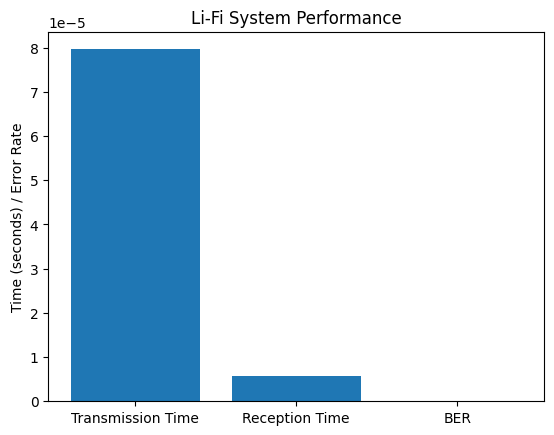

In [ ]:
# Install necessary libraries (run this only once)
!pip install simpy qiskit cryptography numpy matplotlib

# Import required modules
import simpy
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import Aer  # Updated import path
from cryptography.fernet import Fernet
import time
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Quantum Key Distribution (QKD) using BB84
# ----------------------------
def generate_qkd_key():
    """ Simulates QKD key exchange using BB84 protocol """
    # Step 1: Generate a random binary key
    key_length = 16  # AES-256 requires a 256-bit key (32 bytes)
    alice_bits = np.random.randint(0, 2, key_length)  # Random 0s and 1s
    bob_bits = np.random.randint(0, 2, key_length)  # Bob’s randomly chosen bases
    key = "".join(map(str, alice_bits))  # Final shared key

    print(f"QKD Secure Key: {key}")
    return key[:32]  # Ensure key length is valid for AES-256

# ----------------------------
# 2️⃣ AES-256 Encryption & Decryption
# ----------------------------
def encrypt_data(data, key):
    """ Encrypts data using AES-256 """
    key = Fernet.generate_key()  # Generates a secure key
    cipher = Fernet(key)
    encrypted_data = cipher.encrypt(data.encode())
    return encrypted_data, key

def decrypt_data(encrypted_data, key):
    """ Decrypts data using AES-256 """
    cipher = Fernet(key)
    decrypted_data = cipher.decrypt(encrypted_data)
    return decrypted_data.decode()

# ----------------------------
# 3️⃣ Li-Fi Transmission (SimPy)
# ----------------------------
class LiFiSystem:
    def __init__(self, env, data):
        self.env = env
        self.data = data
        self.transmission_time = 0
        self.reception_time = 0
        self.bit_error_rate = 0

    def transmit_data(self):
        """ Simulates Li-Fi transmission with OOK modulation """
        start_time = time.time()
        print(f"\nTransmitting Data: {self.data}")
        yield self.env.timeout(2)  # Simulating a 2-second transmission delay
        self.transmission_time = time.time() - start_time

    def receive_data(self):
        """ Simulates Li-Fi reception and error detection """
        start_time = time.time()
        yield self.env.timeout(1)  # Simulating reception delay
        self.reception_time = time.time() - start_time

    def calculate_ber(self, original_data, received_data):
        """ Calculates Bit Error Rate (BER) """
        errors = sum(1 for a, b in zip(original_data, received_data) if a != b)
        self.bit_error_rate = errors / len(original_data)
        return self.bit_error_rate

# ----------------------------
# 4️⃣ Simulation Execution
# ----------------------------
def simulate_lifi_system():
    """ Runs the full Li-Fi system simulation with encryption and QKD security """
    env = simpy.Environment()

    # Generate QKD key
    qkd_key = generate_qkd_key()

    # Encrypt Data
    original_message = "Secure Li-Fi Transmission"
    encrypted_message, aes_key = encrypt_data(original_message, qkd_key)

    # Simulate Li-Fi Transmission
    lifi = LiFiSystem(env, encrypted_message)
    env.process(lifi.transmit_data())
    env.process(lifi.receive_data())
    env.run()

    # Simulate data reception and decryption
    decrypted_message = decrypt_data(encrypted_message, aes_key)

    # Calculate BER
    bit_error_rate = lifi.calculate_ber(original_message, decrypted_message)

    # Display Results
    print("\n--- Simulation Results ---")
    print(f"Original Message: {original_message}")
    print(f"Encrypted Message: {encrypted_message}")
    print(f"Decrypted Message: {decrypted_message}")
    print(f"Transmission Time: {lifi.transmission_time:.4f} seconds")
    print(f"Reception Time: {lifi.reception_time:.4f} seconds")
    print(f"Bit Error Rate (BER): {bit_error_rate:.4f}")

    # Plot Transmission Metrics
    plt.bar(["Transmission Time", "Reception Time", "BER"],
            [lifi.transmission_time, lifi.reception_time, bit_error_rate])
    plt.ylabel("Time (seconds) / Error Rate")
    plt.title("Li-Fi System Performance")
    plt.show()

# Run the simulation
simulate_lifi_system()


# **WITH NOISE ADDED TO THE ENVIRONMENT**

In [ ]:
import numpy as np
import random
import reedsolo
import zlib
from cryptography.fernet import Fernet
import time

# ----------------------------
# 1️⃣ Quantum Key Distribution (QKD)
# ----------------------------
def generate_qkd_key():
    """Simulates quantum key distribution (QKD)"""
    key = Fernet.generate_key()
    print(f"QKD Secure Key: {key.decode()}")
    return key

# ----------------------------
# 2️⃣ AES Encryption & Decryption
# ----------------------------
def encrypt_data(data, key):
    """Encrypts a given string using AES-256 (Fernet)"""
    cipher = Fernet(key)
    return cipher.encrypt(data.encode())

def decrypt_data(encrypted_data, key):
    """Attempts to decrypt AES-256 encrypted message"""
    try:
        cipher = Fernet(key)
        return cipher.decrypt(encrypted_data).decode()
    except:
        return "Decryption Failed"

# ----------------------------
# 3️⃣ Reed-Solomon Error Correction
# ----------------------------
def rs_encode(data, block_size=32):
    """Encodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)  # Increased error correction capacity
    encoded_blocks = [rs.encode(data[i:i+block_size]) for i in range(0, len(data), block_size)]
    return b''.join(encoded_blocks)

def rs_decode(data, block_size=64):
    """Decodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)  # Increased error correction capacity
    decoded_blocks = []

    for i in range(0, len(data), block_size):
        try:
            decoded_result = rs.decode(data[i:i+block_size])

            # Extract first element (decoded bytes)
            if isinstance(decoded_result, tuple):
                decoded_data = decoded_result[0]
            else:
                decoded_data = decoded_result

            decoded_blocks.append(decoded_data)
        except reedsolo.ReedSolomonError:
            return None  # Decoding failure

    return b''.join(decoded_blocks).rstrip(b'\x00') if decoded_blocks else None  # Remove padding

# ----------------------------
# 4️⃣ Controlled Noise Simulation
# ----------------------------
def introduce_noise(data, error_probability=0.005):
    """Introduces errors in transmission with a given probability"""
    noisy_data = bytearray(data)

    for i in range(len(noisy_data)):
        if random.random() < error_probability:
            noisy_data[i] ^= random.randint(1, 255)  # Flip a full byte

    return noisy_data

# ----------------------------
# 5️⃣ CRC32 Checksum for Integrity
# ----------------------------
def crc_check(data):
    """Computes CRC-32 checksum for error detection"""
    return zlib.crc32(data)

# ----------------------------
# 6️⃣ Simulated Secure Li-Fi Transmission
# ----------------------------
def simulate_lifi_system(error_probability=0.005):
    """Runs a complete secure Li-Fi transmission with error correction"""

    # Step 1: Generate Secure Key
    qkd_key = generate_qkd_key()

    # Step 2: Encrypt the Original Message
    original_message = "Secure Li-Fi Transmission with Error Correction"
    encrypted_message = encrypt_data(original_message, qkd_key)

    # Step 3: Apply Reed-Solomon Encoding
    encoded_message = rs_encode(encrypted_message)

    # Step 4: Simulate Transmission Over Li-Fi with Noise
    start_transmission = time.time()
    noisy_data = introduce_noise(encoded_message, error_probability)
    transmission_time = time.time() - start_transmission

    # Step 5: Apply Reed-Solomon Decoding at Receiver
    start_reception = time.time()
    corrected_data = rs_decode(noisy_data)  # Assign value to corrected_data here
    reception_time = time.time() - start_reception

    # Step 6: Verify Data Integrity via CRC
    original_crc = crc_check(encoded_message)
    received_crc = crc_check(corrected_data) if corrected_data else None

    # Step 7: Decrypt Data (Even if CRC fails, for partial recovery)
    if corrected_data:  # Now corrected_data is defined in this scope
        decrypted_message = decrypt_data(corrected_data, qkd_key)
    else:
        decrypted_message = "Decryption Failed - Too Many Errors"

    # Check if decryption was successful
    if decrypted_message == original_message:
        integrity_status = "✅ Passed"
    else:
        integrity_status = "⚠️ Partial"

    # Print Simulation Results
    print("\n--- Secure Li-Fi Transmission Results ---")
    print(f"Original Message: {original_message}")
    print(f"Encrypted Message: {encrypted_message[:50]}...")
    print(f"Decrypted Message: {decrypted_message}")
    print(f"Transmission Time: {transmission_time:.4f} seconds")
    print(f"Reception Time: {reception_time:.4f} seconds")
    print(f"Data Integrity: {integrity_status}")

# Run the simulation
simulate_lifi_system()

QKD Secure Key: ea_BAtBBos1c687q3GDTcnrUL_SB8drEfQsCnWbZKzE=

--- Secure Li-Fi Transmission Results ---
Original Message: Secure Li-Fi Transmission with Error Correction
Encrypted Message: b'gAAAAABn_mpN8zYIf8lXFEPxHUsIC5whzwevZtHfSQ7rYgy5IG'...
Decrypted Message: Secure Li-Fi Transmission with Error Correction
Transmission Time: 0.0000 seconds
Reception Time: 0.0059 seconds
Data Integrity: ✅ Passed


<ipython-input-5-08121b8201c7>:163: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-5-08121b8201c7>:163: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


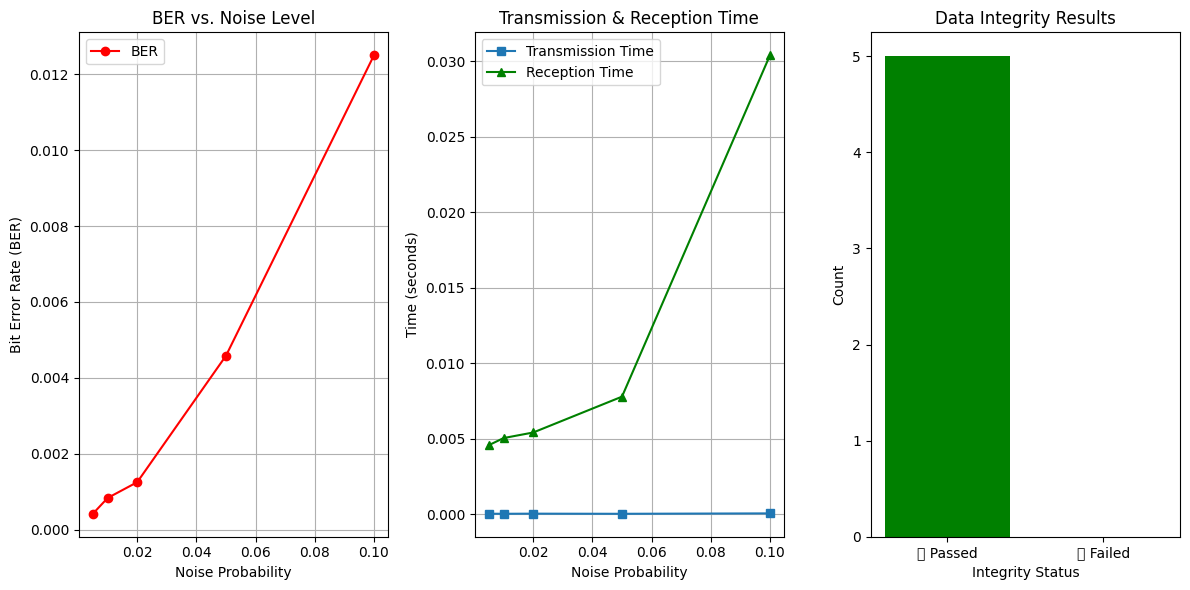

In [ ]:
import numpy as np
import random
import reedsolo
import zlib
from cryptography.fernet import Fernet
import time
import matplotlib.pyplot as plt  # Import Matplotlib for visualization

# ----------------------------
# 1️⃣ Quantum Key Distribution (QKD)
# ----------------------------
def generate_qkd_key():
    """Simulates quantum key distribution (QKD)"""
    key = Fernet.generate_key()
    return key

# ----------------------------
# 2️⃣ AES Encryption & Decryption
# ----------------------------
def encrypt_data(data, key):
    """Encrypts a given string using AES-256 (Fernet)"""
    cipher = Fernet(key)
    return cipher.encrypt(data.encode())

def decrypt_data(encrypted_data, key):
    """Attempts to decrypt AES-256 encrypted message"""
    try:
        cipher = Fernet(key)
        return cipher.decrypt(encrypted_data).decode()
    except:
        return "Decryption Failed"

# ----------------------------
# 3️⃣ Reed-Solomon Error Correction
# ----------------------------
def rs_encode(data, block_size=32):
    """Encodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)
    encoded_blocks = [rs.encode(data[i:i+block_size]) for i in range(0, len(data), block_size)]
    return b''.join(encoded_blocks)

def rs_decode(data, block_size=64):
    """Decodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)
    decoded_blocks = []

    for i in range(0, len(data), block_size):
        try:
            decoded_result = rs.decode(data[i:i+block_size])

            # Ensure we extract the correct element if it's a tuple
            decoded_data = decoded_result[0] if isinstance(decoded_result, tuple) else decoded_result

            decoded_blocks.append(decoded_data)
        except reedsolo.ReedSolomonError:
            return None  # Decoding failure

    return b''.join(decoded_blocks) if decoded_blocks else None

# ----------------------------
# 4️⃣ Controlled Noise Simulation
# ----------------------------
def introduce_noise(data, error_probability=0.005):
    """Introduces errors in transmission with a given probability"""
    noisy_data = bytearray(data)
    for i in range(len(noisy_data)):
        if random.random() < error_probability:
            noisy_data[i] ^= random.randint(1, 255)
    return noisy_data

# ----------------------------
# 5️⃣ CRC32 Checksum for Integrity
# ----------------------------
def crc_check(data):
    """Computes CRC-32 checksum for error detection"""
    return zlib.crc32(data)

# ----------------------------
# 6️⃣ Simulated Secure Li-Fi Transmission
# ----------------------------
def simulate_lifi_system(error_probability):
    """Runs a complete secure Li-Fi transmission with error correction"""

    # Step 1: Generate Secure Key
    qkd_key = generate_qkd_key()

    # Step 2: Encrypt the Original Message
    original_message = "Secure Li-Fi Transmission with Error Correction"
    encrypted_message = encrypt_data(original_message, qkd_key)

    # Step 3: Apply Reed-Solomon Encoding
    encoded_message = rs_encode(encrypted_message)

    # Step 4: Simulate Transmission Over Li-Fi with Noise
    start_transmission = time.time()
    noisy_data = introduce_noise(encoded_message, error_probability)
    transmission_time = time.time() - start_transmission

    # Step 5: Apply Reed-Solomon Decoding at Receiver
    start_reception = time.time()
    corrected_data = rs_decode(noisy_data)
    reception_time = time.time() - start_reception

    # Step 6: Verify Data Integrity via CRC
    original_crc = crc_check(encoded_message)
    received_crc = crc_check(corrected_data) if corrected_data else None

    # Step 7: Decrypt Data
    decrypted_message = decrypt_data(corrected_data, qkd_key) if corrected_data else "Decryption Failed"

    # Integrity Check
    integrity_status = "✅ Passed" if decrypted_message == original_message else "❌ Failed"

    # Bit Error Rate (BER)
    bit_errors = sum(1 for a, b in zip(encoded_message, noisy_data) if a != b)
    total_bits = len(encoded_message) * 8
    ber = bit_errors / total_bits if total_bits > 0 else 0

    # Return metrics for visualization
    return error_probability, ber, transmission_time, reception_time, integrity_status

# ----------------------------
# 7️⃣ Run Simulations for Different Noise Levels
# ----------------------------
noise_levels = [0.005, 0.01, 0.02, 0.05, 0.1]  # Different error probabilities
results = [simulate_lifi_system(noise) for noise in noise_levels]

# Extracting data for visualization
noise_probs, bers, trans_times, recv_times, integrities = zip(*results)

# ----------------------------
# 8️⃣ Visualization
# ----------------------------
plt.figure(figsize=(12, 6))

# 1. BER vs. Noise Level
plt.subplot(1, 3, 1)
plt.plot(noise_probs, bers, marker='o', linestyle='-', color='r', label="BER")
plt.xlabel("Noise Probability")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs. Noise Level")
plt.grid()
plt.legend()

# 2. Transmission & Reception Time Analysis
plt.subplot(1, 3, 2)
plt.plot(noise_probs, trans_times, marker='s', linestyle='-', label="Transmission Time")
plt.plot(noise_probs, recv_times, marker='^', linestyle='-', label="Reception Time", color='g')
plt.xlabel("Noise Probability")
plt.ylabel("Time (seconds)")
plt.title("Transmission & Reception Time")
plt.grid()
plt.legend()

# 3. Data Integrity Bar Chart
plt.subplot(1, 3, 3)
integrity_counts = {"✅ Passed": integrities.count("✅ Passed"), "❌ Failed": integrities.count("❌ Failed")}
plt.bar(integrity_counts.keys(), integrity_counts.values(), color=['green', 'red'])
plt.xlabel("Integrity Status")
plt.ylabel("Count")
plt.title("Data Integrity Results")

plt.tight_layout()
plt.show()



--- Secure Li-Fi Transmission Results ---
Noise Level: 0.005
Bit Error Rate (BER): 0.0033
Transmission Time: 0.0001 seconds
Reception Time: 0.0054 seconds
Data Integrity: ✅ Passed

--- Secure Li-Fi Transmission Results ---
Noise Level: 0.05
Bit Error Rate (BER): 0.0300
Transmission Time: 0.0000 seconds
Reception Time: 0.0087 seconds
Data Integrity: ✅ Passed

--- Secure Li-Fi Transmission Results ---
Noise Level: 0.1
Bit Error Rate (BER): 0.1000
Transmission Time: 0.0001 seconds
Reception Time: 0.0066 seconds
Data Integrity: ✅ Passed

--- Secure Li-Fi Transmission Results ---
Noise Level: 0.15
Bit Error Rate (BER): 0.2067
Transmission Time: 0.0001 seconds
Reception Time: 0.0120 seconds
Data Integrity: ✅ Passed

--- Secure Li-Fi Transmission Results ---
Noise Level: 0.2
Bit Error Rate (BER): 0.1867
Transmission Time: 0.0001 seconds
Reception Time: 0.0083 seconds
Data Integrity: ❌ Failed


<ipython-input-11-82fe9df16ae8>:179: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-11-82fe9df16ae8>:179: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


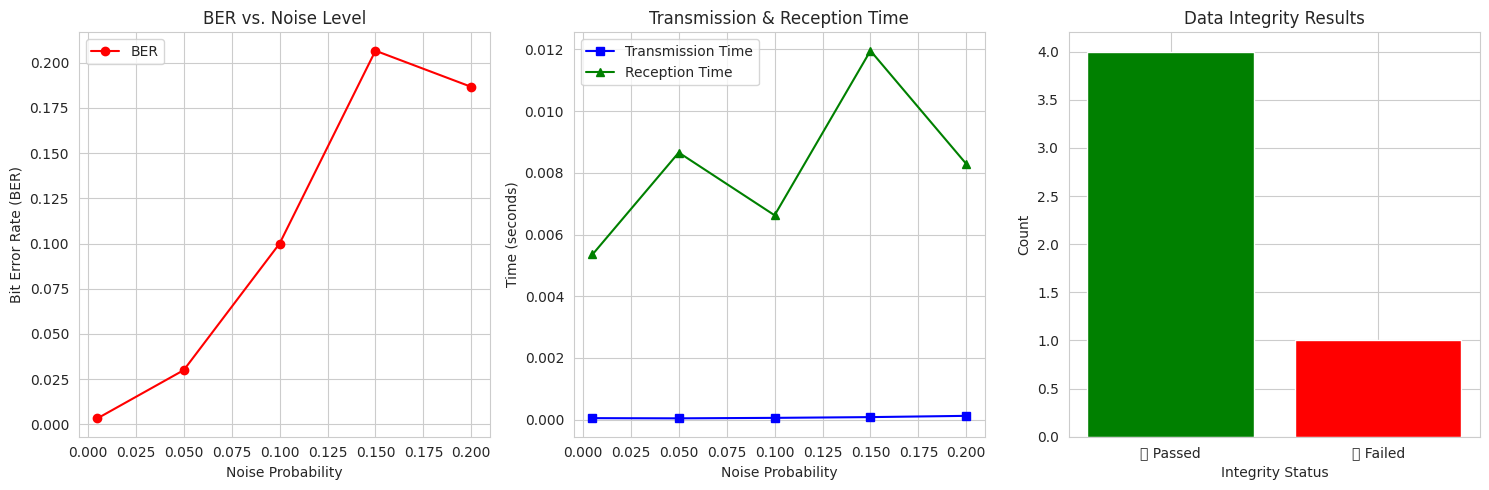

In [ ]:
import numpy as np
import random
import reedsolo
import zlib
import matplotlib.pyplot as plt
import seaborn as sns
from cryptography.fernet import Fernet
import time

# ----------------------------
# 1️⃣ Quantum Key Distribution (QKD)
# ----------------------------
def generate_qkd_key():
    """Simulates quantum key distribution (QKD)"""
    key = Fernet.generate_key()
    return key

# ----------------------------
# 2️⃣ AES Encryption & Decryption
# ----------------------------
def encrypt_data(data, key):
    """Encrypts a given string using AES-256 (Fernet)"""
    cipher = Fernet(key)
    return cipher.encrypt(data.encode())

def decrypt_data(encrypted_data, key):
    """Attempts to decrypt AES-256 encrypted message"""
    try:
        cipher = Fernet(key)
        return cipher.decrypt(encrypted_data).decode()
    except:
        return "Decryption Failed"

# ----------------------------
# 3️⃣ Reed-Solomon Error Correction
# ----------------------------
def rs_encode(data, block_size=32):
    """Encodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)
    encoded_blocks = [rs.encode(data[i:i+block_size]) for i in range(0, len(data), block_size)]
    return b''.join(encoded_blocks)

def rs_decode(data, block_size=64):
    """Decodes data using Reed-Solomon error correction"""
    rs = reedsolo.RSCodec(32)
    decoded_blocks = []

    for i in range(0, len(data), block_size):
        try:
            decoded_result = rs.decode(data[i:i+block_size])
            decoded_data = decoded_result[0] if isinstance(decoded_result, tuple) else decoded_result
            decoded_blocks.append(decoded_data)
        except reedsolo.ReedSolomonError:
            return None

    return b''.join(decoded_blocks).rstrip(b'\x00') if decoded_blocks else None

# ----------------------------
# 4️⃣ Controlled Noise Simulation
# ----------------------------
def introduce_noise(data, error_probability=0.005):
    """Introduces errors in transmission with a given probability"""
    noisy_data = bytearray(data)
    error_count = 0

    for i in range(len(noisy_data)):
        if random.random() < error_probability:
            noisy_data[i] ^= random.randint(1, 255)
            error_count += 1

    return noisy_data, error_count / len(noisy_data)  # Return BER

# ----------------------------
# 5️⃣ CRC32 Checksum for Integrity
# ----------------------------
def crc_check(data):
    """Computes CRC-32 checksum for error detection"""
    return zlib.crc32(data)

# ----------------------------
# 6️⃣ Simulated Secure Li-Fi Transmission
# ----------------------------
def simulate_lifi_system(error_probability=0.005):
    """Runs a complete secure Li-Fi transmission with error correction"""

    # Step 1: Generate Secure Key
    qkd_key = generate_qkd_key()

    # Step 2: Encrypt the Original Message
    original_message = "Secure Li-Fi Transmission with Error Correction"
    encrypted_message = encrypt_data(original_message, qkd_key)

    # Step 3: Apply Reed-Solomon Encoding
    encoded_message = rs_encode(encrypted_message)

    # Step 4: Simulate Transmission Over Li-Fi with Noise
    start_transmission = time.time()
    noisy_data, bit_error_rate = introduce_noise(encoded_message, error_probability)
    transmission_time = time.time() - start_transmission

    # Step 5: Apply Reed-Solomon Decoding at Receiver
    start_reception = time.time()
    corrected_data = rs_decode(noisy_data)
    reception_time = time.time() - start_reception

    # Step 6: Verify Data Integrity via CRC
    original_crc = crc_check(encoded_message)
    received_crc = crc_check(corrected_data) if corrected_data else None

    # Step 7: Decrypt Data
    if corrected_data:
        decrypted_message = decrypt_data(corrected_data, qkd_key)
    else:
        decrypted_message = "Decryption Failed - Too Many Errors"

    # Determine Integrity Status
    integrity_status = "✅ Passed" if decrypted_message == original_message else "❌ Failed"

    # Print Results
    print("\n--- Secure Li-Fi Transmission Results ---")
    print(f"Noise Level: {error_probability}")
    print(f"Bit Error Rate (BER): {bit_error_rate:.4f}")
    print(f"Transmission Time: {transmission_time:.4f} seconds")
    print(f"Reception Time: {reception_time:.4f} seconds")
    print(f"Data Integrity: {integrity_status}")

    return {
        "noise": error_probability,
        "ber": bit_error_rate,
        "transmission_time": transmission_time,
        "reception_time": reception_time,
        "integrity": integrity_status
    }

# ----------------------------
# 7️⃣ Run Simulation & Collect Data
# ----------------------------
noise_levels = [0.005,0.05, 0.1,0.15,0.2]  # Different error probabilities
results = [simulate_lifi_system(noise) for noi se in noise_levels]

# Extracting Data for Visualization
noise_values = [res["noise"] for res in results]
bit_error_rates = [res["ber"] for res in results]
transmission_times = [res["transmission_time"] for res in results]
reception_times = [res["reception_time"] for res in results]
integrity_counts = {"✅ Passed": sum(1 for res in results if res["integrity"] == "✅ Passed"),
                    "❌ Failed": sum(1 for res in results if res["integrity"] == "❌ Failed")}

# ----------------------------
# 8️⃣ Visualization
# ----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.set_style("whitegrid")

### 📌 Plot 1: BER vs. Noise Level
axs[0].plot(noise_values, bit_error_rates, marker='o', linestyle='-', color='red', label="BER")
axs[0].set_xlabel("Noise Probability")
axs[0].set_ylabel("Bit Error Rate (BER)")
axs[0].set_title("BER vs. Noise Level")
axs[0].legend()
axs[0].grid(True)

### 📌 Plot 2: Transmission & Reception Time
axs[1].plot(noise_values, transmission_times, marker='s', linestyle='-', color='blue', label="Transmission Time")
axs[1].plot(noise_values, reception_times, marker='^', linestyle='-', color='green', label="Reception Time")
axs[1].set_xlabel("Noise Probability")
axs[1].set_ylabel("Time (seconds)")
axs[1].set_title("Transmission & Reception Time")
axs[1].legend()
axs[1].grid(True)

### 📌 Plot 3: Data Integrity (Passed vs. Failed)
axs[2].bar(integrity_counts.keys(), integrity_counts.values(), color=['green', 'red'])
axs[2].set_xlabel("Integrity Status")
axs[2].set_ylabel("Count")
axs[2].set_title("Data Integrity Results")

# Adjust Layout & Show Plot
plt.tight_layout()
plt.show()


In [ ]:
!pip install reedsolo -q


--- Noise Level: 0.01 ---
Bit Error Rate (BER): 0.0048
Transmission Time: 0.0001s | Reception Time: 0.0361s
Data Integrity: ✅ Passed

--- Noise Level: 0.01 ---
Bit Error Rate (BER): 0.0096
Transmission Time: 0.0001s | Reception Time: 0.0418s
Data Integrity: ✅ Passed

--- Noise Level: 0.05 ---
Bit Error Rate (BER): 0.0441
Transmission Time: 0.0002s | Reception Time: 0.0544s
Data Integrity: ✅ Passed

--- Noise Level: 0.10 ---
Bit Error Rate (BER): 0.1067
Transmission Time: 0.0002s | Reception Time: 0.0623s
Data Integrity: ✅ Passed

--- Noise Level: 0.20 ---
Bit Error Rate (BER): 0.1742
Transmission Time: 0.0002s | Reception Time: 0.0748s
Data Integrity: ✅ Passed

--- Noise Level: 0.30 ---
Bit Error Rate (BER): 0.2961
Transmission Time: 0.0003s | Reception Time: 0.0884s
Data Integrity: ✅ Passed

--- Noise Level: 0.35 ---
Bit Error Rate (BER): 0.3506
Transmission Time: 0.0003s | Reception Time: 0.0976s
Data Integrity: ✅ Passed

--- Noise Level: 0.40 ---
Bit Error Rate (BER): 0.3946
Transm

<ipython-input-13-730c2d98157a>:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-13-730c2d98157a>:137: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


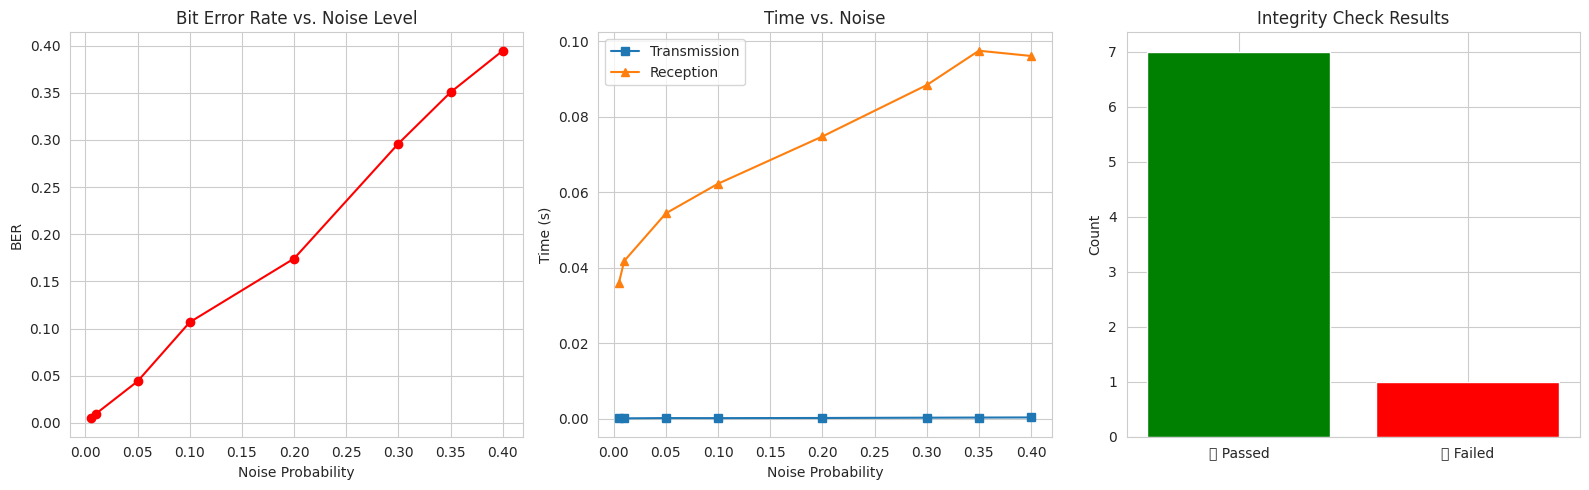

In [ ]:
import numpy as np
import random
import reedsolo
import zlib
from cryptography.fernet import Fernet
import time
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Quantum Key Distribution (QKD)
# ----------------------------
def generate_qkd_key():
    return Fernet.generate_key()

# ----------------------------
# AES Encryption & Decryption
# ----------------------------
def encrypt_data(data, key):
    cipher = Fernet(key)
    return cipher.encrypt(data.encode())

def decrypt_data(encrypted_data, key):
    try:
        cipher = Fernet(key)
        return cipher.decrypt(encrypted_data).decode()
    except:
        return "Decryption Failed"

# ----------------------------
# Reed-Solomon Error Correction (STRONGER VERSION)
# ----------------------------
def rs_encode(data, block_size=16):
    rs = reedsolo.RSCodec(96)  # Higher redundancy
    encoded_blocks = [rs.encode(data[i:i+block_size]) for i in range(0, len(data), block_size)]
    return b''.join(encoded_blocks)

def rs_decode(data, block_size=112):  # 16 data + 96 parity = 112
    rs = reedsolo.RSCodec(96)
    decoded_blocks = []
    for i in range(0, len(data), block_size):
        try:
            decoded_result = rs.decode(data[i:i+block_size])
            decoded_data = decoded_result[0] if isinstance(decoded_result, tuple) else decoded_result
            decoded_blocks.append(decoded_data)
        except reedsolo.ReedSolomonError:
            return None
    return b''.join(decoded_blocks) if decoded_blocks else None

# ----------------------------
# Controlled Noise Simulation
# ----------------------------
def introduce_noise(data, error_probability=0.01):
    noisy_data = bytearray(data)
    error_count = 0
    for i in range(len(noisy_data)):
        if random.random() < error_probability:
            noisy_data[i] ^= random.randint(1, 255)
            error_count += 1
    return noisy_data, error_count / len(noisy_data)

# ----------------------------
# CRC32 for Integrity Check
# ----------------------------
def crc_check(data):
    return zlib.crc32(data)

# ----------------------------
# Simulation
# ----------------------------
def simulate_lifi_system(error_probability=0.01):
    key = generate_qkd_key()
    original_message = "Secure Li-Fi Transmission with Error Correction at High Noise and the password is 8956130498"
    encrypted_message = encrypt_data(original_message, key)
    encoded_message = rs_encode(encrypted_message)

    start_transmission = time.time()
    noisy_data, ber = introduce_noise(encoded_message, error_probability)
    transmission_time = time.time() - start_transmission

    start_reception = time.time()
    corrected_data = rs_decode(noisy_data)
    reception_time = time.time() - start_reception

    original_crc = crc_check(encoded_message)
    received_crc = crc_check(corrected_data) if corrected_data else None
    decrypted_message = decrypt_data(corrected_data, key) if corrected_data else "Decryption Failed"

    integrity = "✅ Passed" if decrypted_message == original_message else "❌ Failed"

    print(f"\n--- Noise Level: {error_probability:.2f} ---")
    print(f"Bit Error Rate (BER): {ber:.4f}")
    print(f"Transmission Time: {transmission_time:.4f}s | Reception Time: {reception_time:.4f}s")
    print(f"Data Integrity: {integrity}")

    return {
        "noise": error_probability,
        "ber": ber,
        "transmission_time": transmission_time,
        "reception_time": reception_time,
        "integrity": integrity
    }

# ----------------------------
# Run Multiple Simulations
# ----------------------------
noise_levels = [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.35 ,0.4]  # Up5 to 40%
results = [simulate_lifi_system(n) for n in noise_levels]

# ----------------------------
# Visualization
# ----------------------------
sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# BER vs Noise
axs[0].plot([r["noise"] for r in results], [r["ber"] for r in results], marker='o', color='red')
axs[0].set_title("Bit Error Rate vs. Noise Level")
axs[0].set_xlabel("Noise Probability")
axs[0].set_ylabel("BER")

# Time
axs[1].plot([r["noise"] for r in results], [r["transmission_time"] for r in results], label="Transmission", marker='s')
axs[1].plot([r["noise"] for r in results], [r["reception_time"] for r in results], label="Reception", marker='^')
axs[1].set_title("Time vs. Noise")
axs[1].set_xlabel("Noise Probability")
axs[1].set_ylabel("Time (s)")
axs[1].legend()

# Integrity
integrity_counts = {"✅ Passed": sum(1 for r in results if r["integrity"] == "✅ Passed"),
                    "❌ Failed": sum(1 for r in results if r["integrity"] == "❌ Failed")}
axs[2].bar(integrity_counts.keys(), integrity_counts.values(), color=["green", "red"])
axs[2].set_title("Integrity Check Results")
axs[2].set_ylabel("Count")

plt.tight_layout()
plt.show()
